# 05 — Business-Friendly Baseline and Peer-Strategy A/B

This notebook keeps S2 as the business-friendly operational baseline and changes one decision at a
time: channel peers, company/division peers, or an as-of hybrid fallback. Company/division
residuals are recomputed within each monthly peer cell.

Evaluation uses exact monthly capacities of 100, 250, and 500 cases. No raw company/division
codes or absolute commercial values are loaded or displayed.

**Notebook structure:** aggregate data-quality checks are followed by fixed-capacity peer
comparisons and the decision boundary. The charts measure queue sensitivity. Commercial
usefulness is evaluated through the blinded review.


## Business understanding

GelatiCo's commercial teams cannot manually monitor roughly 17,000 B2B customers every month. The
goal of this notebook sequence is to turn historical order data into a prioritized,
business-friendly queue of customer-months for human review. There are no confirmed anomaly
labels for this problem, so success is measured by
queue agreement, stability, and eventually a blinded commercial pilot rather than by accuracy
against anomaly ground truth.

This notebook asks whether the peer definition changes who gets flagged: channel peers,
company/division peers, or an as-of hybrid fallback. Later notebooks add an independent cadence
lens and convert both lenses into a practical review queue.


## Data cleaning and quality verification

This workflow starts from an authorized private checkpoint and performs bounded preparation
before scoring. The code
below parses the month key, removes rows with invalid keys, removes duplicate customer-months,
normalizes sparse and zero-order flags, coerces numeric inputs, sorts deterministically, and passes
that cleaned frame directly into the peer-strategy evaluation. Genuinely unknown continuous
measurements remain missing.

A left-join miss denotes no activity rather than an unknown value; genuinely unknown continuous
measurements remain missing rather than silently imputed.


In [1]:
# ruff: noqa: E402
import sys
from pathlib import Path

ROOT = Path('..').resolve()
SRC = ROOT / 'src'
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

import pandas as pd
from module24_workflow import PEER_INPUT_COLUMNS, S2_PATH, run_peer_strategy_evaluation

# Load only the fields required by this experiment, then clean the inherited checkpoint here.
raw_peer_input = pd.read_parquet(S2_PATH, columns=PEER_INPUT_COLUMNS)
peer_input = raw_peer_input.copy()
peer_input['transaction_month'] = pd.to_datetime(
    peer_input['transaction_month'], errors='coerce'
)

missing_key_rows = peer_input[
    ['customer_public_id', 'transaction_month']
].isna().any(axis=1)
peer_input = peer_input.loc[~missing_key_rows].copy()
rows_before_deduplication = len(peer_input)
peer_input = peer_input.drop_duplicates(
    ['customer_public_id', 'transaction_month'], keep='last'
)
duplicate_rows_removed = rows_before_deduplication - len(peer_input)

sparse_flag_columns = [
    'sparse_history_flag',
    'sparse_peer_group_flag',
    'sparse_company_division_peer_group_flag',
]
sparse_flags_filled = int(peer_input[sparse_flag_columns].isna().sum().sum())
peer_input[sparse_flag_columns] = (
    peer_input[sparse_flag_columns].fillna(True).astype(bool)
)
zero_order_flags_filled = int(peer_input['zero_order_month_flag'].isna().sum())
peer_input['zero_order_month_flag'] = (
    peer_input['zero_order_month_flag'].fillna(False).astype(bool)
)

non_numeric_columns = {
    'customer_public_id',
    'transaction_month',
    'company_division_peer_public_id',
    *sparse_flag_columns,
    'zero_order_month_flag',
}
numeric_columns = [
    column for column in PEER_INPUT_COLUMNS if column not in non_numeric_columns
]
numeric_missing_before = int(peer_input[numeric_columns].isna().sum().sum())
peer_input[numeric_columns] = peer_input[numeric_columns].apply(
    pd.to_numeric, errors='coerce'
)
numeric_values_coerced = (
    int(peer_input[numeric_columns].isna().sum().sum()) - numeric_missing_before
)
peer_input = peer_input.sort_values(
    ['customer_public_id', 'transaction_month'], kind='mergesort'
).reset_index(drop=True)

assert not peer_input.duplicated(
    ['customer_public_id', 'transaction_month']
).any()
assert peer_input['transaction_month'].notna().all()

cleaning_summary = pd.DataFrame(
    [
        {'Cleaning action': 'Rows loaded', 'Affected rows or values': len(raw_peer_input)},
        {
            'Cleaning action': 'Missing or invalid key rows removed',
            'Affected rows or values': int(missing_key_rows.sum()),
        },
        {
            'Cleaning action': 'Duplicate customer-month rows removed',
            'Affected rows or values': duplicate_rows_removed,
        },
        {
            'Cleaning action': 'Missing sparse flags filled conservatively',
            'Affected rows or values': sparse_flags_filled,
        },
        {
            'Cleaning action': 'Missing zero-order flags filled',
            'Affected rows or values': zero_order_flags_filled,
        },
        {
            'Cleaning action': 'Invalid numeric values coerced to missing',
            'Affected rows or values': numeric_values_coerced,
        },
        {'Cleaning action': 'Rows passed to scoring', 'Affected rows or values': len(peer_input)},
    ]
)
display(cleaning_summary)

# This notebook-owned object is the exact compact S2 formula used by the workflow call.
s2_score_config = {
    'aggregation': 'maximum_absolute_signal',
    'zero_order_bonus': 0.75,
    'sparse_history_multiplier': 0.75,
}
metrics, peer_output = run_peer_strategy_evaluation(
    s2_score_config=s2_score_config,
    prepared_frame=peer_input,
)
print(f"Evaluated {len(peer_output):,} forward customer-months.")
print(f"Scoring input: {metrics['peer_input_source']} ({metrics['peer_input_rows']:,} rows).")
display(pd.DataFrame([s2_score_config]).rename(index={0: 'S2 configuration'}))
display(pd.DataFrame(metrics['strategy_metrics']).round(4))
display(pd.DataFrame(metrics['capacity_overlap']).round(4))
display(pd.DataFrame([metrics['baseline_reproduction']]).round(4))


,Cleaning action,Affected rows or values
0,Rows loaded,564144
1,Missing or invalid key rows removed,0
2,Duplicate customer-month rows removed,0
3,Missing sparse flags filled conservatively,0
4,Missing zero-order flags filled,0
5,Invalid numeric values coerced to missing,0
6,Rows passed to scoring,564144


Evaluated 98,937 forward customer-months.
Scoring input: caller_prepared_frame (564,144 rows).


,aggregation,zero_order_bonus,sparse_history_multiplier
S2 configuration,maximum_absolute_signal,0.75,0.75


,strategy,forward_rows,sparse_peer_rate,spearman_vs_channel,pearson_vs_channel
0,channel,98937,0.0010,1.0000,1.0000
1,company_division,98937,0.0110,0.7993,0.9079
2,hybrid,98937,0.0007,0.8037,0.9086


,capacity_per_month,comparison,pooled_jaccard,changed_customer_months,mean_monthly_jaccard
0,100,channel_vs_company_division,0.6973,214,0.6985
1,100,channel_vs_hybrid,0.6973,214,0.6985
2,250,channel_vs_company_division,0.8450,252,0.8455
3,250,channel_vs_hybrid,0.8450,252,0.8455
4,500,channel_vs_company_division,0.8634,440,0.8641
5,500,channel_vs_hybrid,0.8645,436,0.8652


,pearson_recomputed_channel_vs_current_s2,spearman_recomputed_channel_vs_current_s2
0,0.9983,1.0


### Post-cleaning quality audit

The compact aggregate audit below verifies the cleaned frame's grain, month coverage, and score
completeness after the three peer strategies run. A zero missing-score count is expected because
sparse company/division cells use the documented fallback rather than producing a null score.


In [2]:
# Display aggregate checks without exposing customer identifiers.
quality_values = metrics['data_quality'].copy()
score_null_counts = quality_values.pop('s2_score_null_counts')
quality_values.update(
    {f'{strategy}_s2_null_rows': rows for strategy, rows in score_null_counts.items()}
)
data_quality = pd.DataFrame([quality_values]).T
data_quality.columns = ['Observed value']
display(data_quality)

null_summary = (
    peer_output[['channel_s2_score', 'company_division_s2_score', 'hybrid_s2_score']]
    .isna()
    .sum()
    .rename('Missing rows')
    .to_frame()
)
null_summary['Missing rate'] = (null_summary['Missing rows'] / len(peer_output)).round(4)
display(null_summary)
print(
    f"Rows checked: {len(peer_output):,}. All three score variants should have zero missing "
    "values because sparse peer cells use an explicit fallback."
)


,Observed value
customer_month_rows,564144
distinct_customers,17128
months,49
month_start,2022-06-01 00:00:00
month_end,2026-06-01 00:00:00
duplicate_customer_month_rows,0
zero_order_month_rate,0.78261
sparse_history_rate,0.175375
channel_s2_null_rows,0
company_division_s2_null_rows,0


,Missing rows,Missing rate
channel_s2_score,0,0.0
company_division_s2_score,0,0.0
hybrid_s2_score,0,0.0


Rows checked: 98,937. All three score variants should have zero missing values because sparse peer cells use an explicit fallback.


## Exploratory data analysis

The monthly activity rate shows whether the share of customer-months with an order changes over
the history available to the workflow. The S2 distribution then shows the continuous score used
to rank cases. These are aggregate diagnostics; they reveal no monetary values or customer IDs.


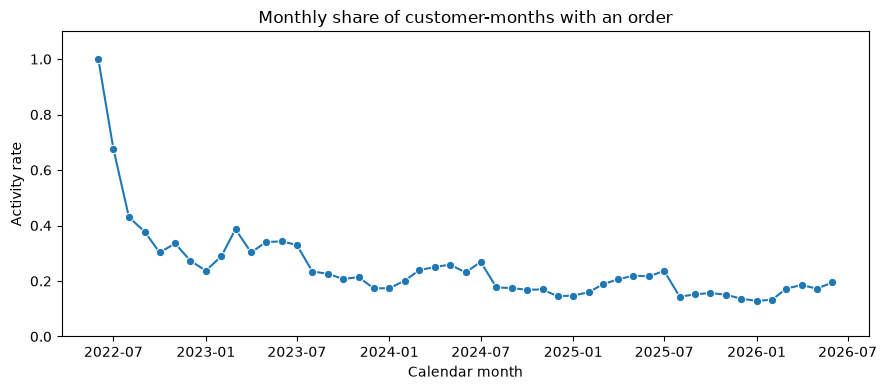

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

FIGURES_DIR = ROOT / 'figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
monthly_activity = pd.DataFrame(metrics['monthly_activity_rate'])
monthly_activity['transaction_month'] = pd.to_datetime(
    monthly_activity['transaction_month']
)
fig, ax = plt.subplots(figsize=(9, 4))
sns.lineplot(
    data=monthly_activity,
    x='transaction_month',
    y='activity_rate',
    marker='o',
    ax=ax,
)
ax.set_title('Monthly share of customer-months with an order')
ax.set_xlabel('Calendar month')
ax.set_ylabel('Activity rate')
ax.set_ylim(0, max(0.25, monthly_activity['activity_rate'].max() * 1.1))
plt.tight_layout()
fig.savefig(FIGURES_DIR / 'monthly_activity_rate.png', dpi=150, bbox_inches='tight')
plt.show()


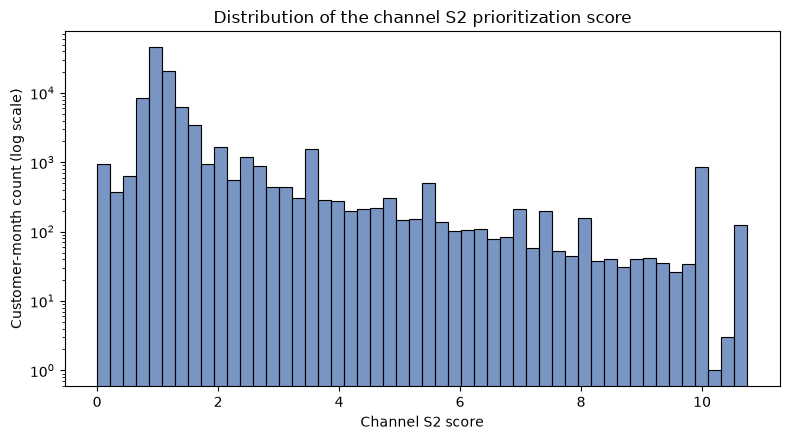

In [4]:
# A logarithmic count axis keeps the common scores and the rare tail visible.
fig, ax = plt.subplots(figsize=(8, 4.5))
sns.histplot(
    data=peer_output,
    x='channel_s2_score',
    bins=50,
    color='#4C72B0',
    ax=ax,
)
ax.set_yscale('log')
ax.set_title('Distribution of the channel S2 prioritization score')
ax.set_xlabel('Channel S2 score')
ax.set_ylabel('Customer-month count (log scale)')
plt.tight_layout()
plt.show()


**Interpretation.** The initially high activity rate is a panel-start boundary
effect, when the available history is shortest, so it should not be read as a business trend.
After that startup period the rate settles substantially lower, with the recent test months in the
mid-teens. The channel S2 score is strongly right-skewed: most customer-months sit near the center
and a much smaller tail receives high priority. S2 is therefore a relative ranking score, not a
probability that a case is a true anomaly.


## Visual diagnostics

The plots compare queue membership and peer-group coverage at the operating capacities. A direct
pandas summary then confirms that the three scores use comparable scales.


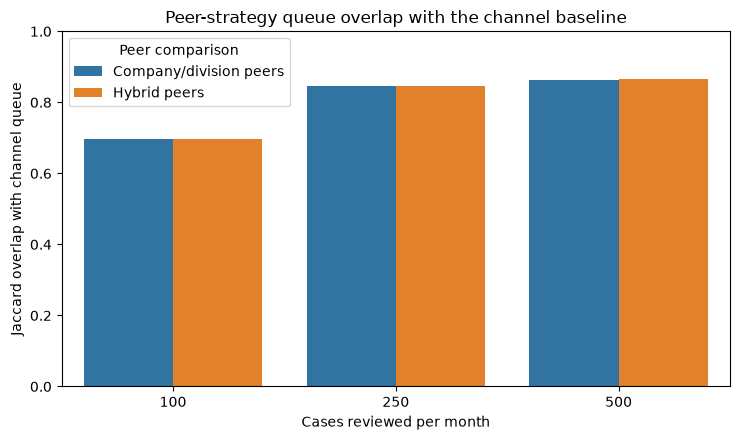

In [5]:
# Compare identical monthly review capacities across peer definitions.
comparison_labels = {
    'channel_vs_company_division': 'Company/division peers',
    'channel_vs_hybrid': 'Hybrid peers',
}
overlap = pd.DataFrame(metrics['capacity_overlap']).assign(
    **{'Peer comparison': lambda frame: frame['comparison'].map(comparison_labels)}
)
fig, ax = plt.subplots(figsize=(7.5, 4.5))
sns.barplot(
    data=overlap,
    x='capacity_per_month',
    y='pooled_jaccard',
    hue='Peer comparison',
    ax=ax,
)
ax.set_title('Peer-strategy queue overlap with the channel baseline')
ax.set_xlabel('Cases reviewed per month')
ax.set_ylabel('Jaccard overlap with channel queue')
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()


**Interpretation.** Peer choice matters most at the tightest monthly capacity:
the top-100 company/division queue changes more cases relative to channel than the top-250 or
top-500 queues. The result supports testing peer definitions at the actual review capacity rather
than treating a pooled score correlation as sufficient evidence.


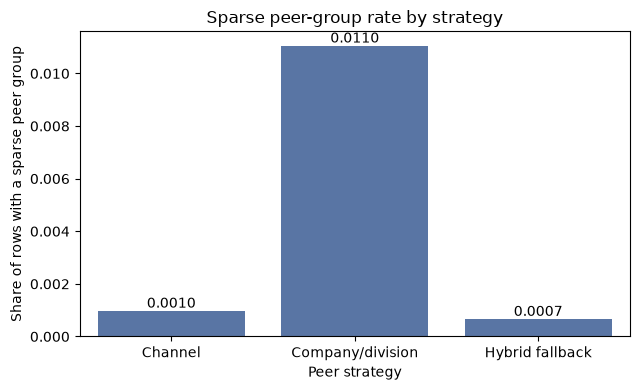

In [6]:
strategy_labels = {
    'channel': 'Channel',
    'company_division': 'Company/division',
    'hybrid': 'Hybrid fallback',
}
strategy_df = pd.DataFrame(metrics['strategy_metrics']).assign(
    **{'Peer strategy': lambda frame: frame['strategy'].map(strategy_labels)}
)
fig, ax = plt.subplots(figsize=(6.5, 4))
sns.barplot(
    data=strategy_df,
    x='Peer strategy',
    y='sparse_peer_rate',
    ax=ax,
    color='#4C72B0',
)
ax.set_title('Sparse peer-group rate by strategy')
ax.set_xlabel('Peer strategy')
ax.set_ylabel('Share of rows with a sparse peer group')
for container in ax.containers:
    ax.bar_label(container, fmt='%.4f')
plt.tight_layout()
plt.show()


**Interpretation.** Company/division has more unusable or sparse peer cells
than channel. The hybrid reduces that operational gap by falling back to channel when the
company/division cell is not usable. Commercial performance by peer definition is evaluated
through the blinded review.


## Final peer-strategy rationale

Channel, company/division, and hybrid peer definitions are evaluated under the same scoring and
capacity rules. Channel is retained as the business-friendly operating lens; the other definitions
remain comparative evidence for the blinded review.

Company/division is assessed for sparse peer cells and queue changes relative to channel. The
hybrid uses company/division when the as-of cell is sufficiently populated and otherwise uses
channel. Commercial correctness requires blinded review outcomes.


In [7]:
score_summary = (
    peer_output[['channel_s2_score', 'company_division_s2_score', 'hybrid_s2_score']]
    .rename(
        columns={
            'channel_s2_score': 'Channel S2',
            'company_division_s2_score': 'Company/division S2',
            'hybrid_s2_score': 'Hybrid S2',
        }
    )
    .describe()
    .round(4)
)
display(score_summary)

display(pd.DataFrame(metrics['score_distribution']).round(4))
tail = metrics['company_division_tail_diagnostic']
tail_diagnostic = pd.DataFrame([tail])
display(tail_diagnostic)
print(
    f"The three strategies are similar through the 99th percentile. The company/division "
    f"maximum ({tail['max_score']:.2f}) comes from a peer cell with "
    f"{tail['max_score_company_division_peer_customer_count']:,} customers and sparse-cell="
    f"{tail['max_score_uses_sparse_company_division_peer_cell']}. Sparse cells therefore did "
    "not manufacture that rare uncapped maximum, and the hybrid inherits it because it keeps "
    "usable company/division cells."
)


,Channel S2,Company/division S2,Hybrid S2
count,98937.0000,98937.0000,98937.0000
mean,1.4345,1.3941,1.3947
std,1.3807,1.4840,1.4846
min,0.0002,0.0000,0.0001
25%,0.9163,0.9025,0.9025
50%,1.0197,0.9831,0.9831
75%,1.2050,1.1582,1.1582
max,10.7500,36.5257,36.5257


,strategy,mean,median,p95,p99,max
0,channel,1.4345,1.0197,3.6357,9.8401,10.7500
1,company_division,1.3941,0.9831,3.5012,10.0000,36.5257
2,hybrid,1.3947,0.9831,3.5012,10.0000,36.5257


,window,max_score,max_score_uses_sparse_company_division_peer_cell,max_score_company_division_peer_customer_count,max_score_peer_residual_rows,top_one_percent_rows,top_one_percent_sparse_company_division_peer_cell_rate
0,forward,36.525737,False,2594,708,1021,0.006856


The three strategies are similar through the 99th percentile. The company/division maximum (36.53) comes from a peer cell with 2,594 customers and sparse-cell=False. Sparse cells therefore did not manufacture that rare uncapped maximum, and the hybrid inherits it because it keeps usable company/division cells.


## Decision boundary

This experiment measures queue sensitivity. Business precision is evaluated separately. Channel
remains the incumbent until commercial reviewers validate the meaning and usefulness of the
changed cases. The hybrid applies an explicit fallback when company/division cells are too small
and retains scores from usable cells without additional capping.
